In [1]:
%pwd

'C:\\Users\\Antonio\\anaconda_projects\\0e04bdeb-c3a2-4548-99dd-9943c5554a32'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("urbandata.csv") ##load dataset

#undeustand basic information about the dataset
print(data.head())
print(data.info())
print("Failure counts:\n", data["failure"].value_counts())



   inspector_id  material_flexibility  structural_mass_ratio  \
0             5             31.762605              12.891996   
1             7             30.770158              11.835563   
2             6             31.591296              11.738267   
3             5             30.834649              11.622881   
4             2             33.315981              12.616065   

   recent_precipitation  infrastructure_age  surface_debris  \
0              4.711064           71.480592        9.429642   
1              3.315888           60.300892        8.655641   
2              2.425562           56.367965        9.017137   
3              2.164486           53.135138        8.864650   
4              4.557082           77.482269        9.549344   

   vibration_exposure  asset_density inspection_season inspection_window  \
0            5.177088         2.9944            summer         afternoon   
1            4.927622         2.6808            spring           morning   
2       

ANALYSIS:

Loaded data and I see 456 rows + 12 columns.
head + info - all info about the dataset  (important - 8 numeric and 2 categorical features) 
failure: 288 non-failures (0) and 168 failures - a bit imbalanced


In [4]:
# more numeric valyues and start looking for missing values

print(data.describe())

print("\nMissing values per column:")
print(data.isna().sum())

       inspector_id  material_flexibility  structural_mass_ratio  \
count    456.000000            456.000000             455.000000   
mean       5.730263             32.592037              12.089241   
std        2.921622              4.738187               0.591701   
min        1.000000             24.924765              11.506094   
25%        3.000000             30.496861              11.672524   
50%        6.000000             31.902116              11.863909   
75%        8.000000             34.026756              12.332858   
max       11.000000             91.157913              14.823489   

       recent_precipitation  infrastructure_age  surface_debris  \
count            454.000000          452.000000      456.000000   
mean               3.110861           68.532487        9.271769   
std                1.365354           14.490899        0.790136   
min                0.000000           41.087602        7.426926   
25%                2.140594           58.594494     

ANALYSIS:

- Sensible ranges
- precipation go from 0 to 6
- debris is 7-12
- density 2.2-3.4

Important is AGE, as it is usually between 40 and 80, but some rows sit as 126. Not realistic. 

little missing values presented - maximum 4 


##PLOTS AND HISTOGRAMS##

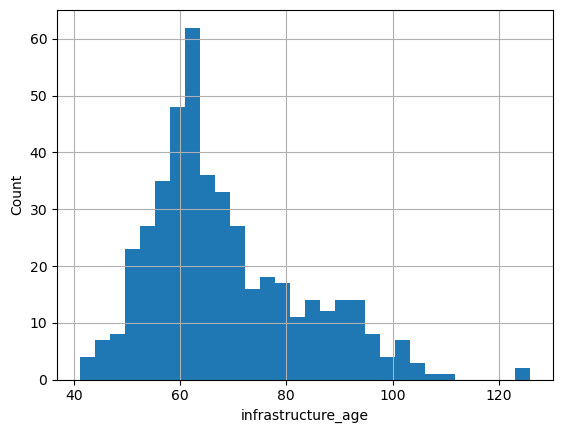

In [5]:
#spot any outliers
data["infrastructure_age"].hist(bins=30)
plt.xlabel("infrastructure_age")
plt.ylabel("Count")
plt.show()

In [6]:
#remove unrealistic ages - essentially over 110 years 

data = data[data["infrastructure_age"] <=110]

#drop remaining rows with missing values
data = data.dropna()

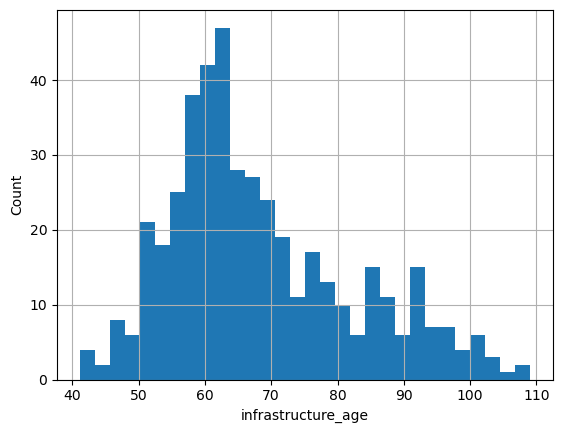

In [7]:
# check again the histo to see if the values have been removed

data["infrastructure_age"].hist(bins=30)
plt.xlabel("infrastructure_age")
plt.ylabel("Count")
plt.show()

ANALYSIS: 
In the previous histogram I noticed that there were values above 120 years old which is not realistic for this dataset and scenario. I removed the rows where age was above 110 then dropped rows with no values. I then plotted again a histo to confirm that what i did was done correctly

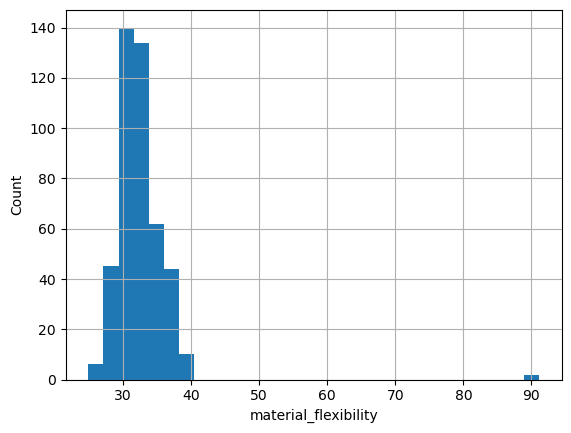

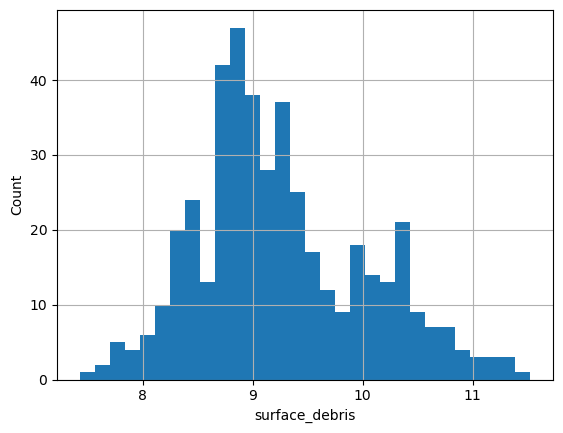

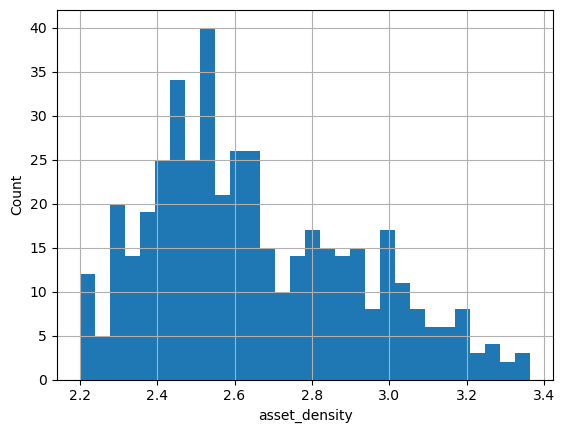

In [8]:
# Distributions?

cols_to_plot = ["material_flexibility","surface_debris", "asset_density"]

for col in cols_to_plot:
    data[col].hist(bins=30)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


ANALYSIS 
- single peaked distributionw with no negative or impossible values 
- reasonably spread
= no extra cleaning needed

this is a unimodal distribution with plausible ranges and no clear outliers (no negative values_ so no further cleaning required.

In [9]:
# correlation with failure

corr = data.corr(numeric_only=True)["failure"].sort_values(ascending=False)
print("\Correlation with failure:")
print(corr)

\Correlation with failure:
failure                  1.000000
surface_debris           0.709258
asset_density            0.691683
recent_precipitation     0.666937
infrastructure_age       0.653302
structural_mass_ratio    0.577638
material_flexibility     0.331907
moisture_stress          0.308255
vibration_exposure       0.277180
inspector_id             0.011621
Name: failure, dtype: float64


ANALYSIS:
Lowest but still positive
materialflexibility, moisturestress and vibration exposure 

highest:
debris, asset density, precipitation, age and structural mass ratio 

this means that blocks with more assets, higher recent precipitations and more debris but also older are more likely to experience failure.



In [15]:
#one hot encode for categorical variables (text to nr)

data_enc = pd.get_dummies(
    data,
    columns = ["inspection_season","inspection_window"],
    drop_first=True
)

#feature x and target y 

X = data_enc.drop(columns=["failure"])
Y = data_enc["failure"]


ANALYSIS
Categorical with one hot encosing means the model does not assume an order between time of day or seasons but it increases the number of input features  --- dummy variable 


TRAIN + VALIDATION + TEST SPLIT

In [18]:
from sklearn.model_selection import train_test_split  

# 60% AND 40 % 

X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.4, random_state=42, stratify=Y
)

#split temp into validation and test -20%/20%

X_val, X_test, y_val,y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape[0])
print("Validation Size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 265
Validation Size: 89
Test size: 89


ANALYSIS:

Data split into 3 parts:

- First: training set - 265 rows and 60%: fit model + learn patterns (TRAIN)

- Second: Validation (89 rows and 20%): choose model and tune setting  (VALIDATION)

- Test: (89 rows and 20%) -- estimate how the final model will perform on unseen and new data (TEST)

STRATISFY -- keeps the failure 1/0 balance very similar in the 3 sets so every single split have a realistic mix of non failuures but also failures.



In [19]:
from sklearn.preprocessing import StandardScaler

#Scale Features 

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

ANALYSIS

StandardScaler has the power of standardising each numeric feature so mean 0 and sd 1 in the training set 

then  fit-transformer- x-train learns the scaling from the data and applies to x train

transform xval + transform xtest have the same scaling to validation and test so no info is leaked from the sets into training. 


TRAIN 3 SIMPLE MODELS

## First Model - LOGISTIC REGRESSION ##

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s,y_train)

y_val_pred_lr = log_reg.predict(X_val_s)
acc_lr = accuracy_score(y_val, y_val_pred_lr)
f1_lr = f1_score(y_val, y_val_pred_lr)

print("Logistic Regression - val accuracy:", acc_lr)
print("Logistic Regression - val F1", f1_lr)

Logistic Regression - val accuracy: 0.9438202247191011
Logistic Regression - val F1 0.9206349206349206


### ANALYSIS FOR LOGISTIC REGRESSION ###

L.R. classified 94% of blocks and hit F1 score of 0.92 for failure.
This means that it balances precision and knows well how to predict failure.

## SECOND MODEL - DECISION TREE ##

In [27]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

y_val_pred_tree = tree.predict(X_val)
acc_tree = accuracy_score(y_val, y_val_pred_tree)
f1_tree = f1_score(y_val, y_val_pred_tree)

print("Decision Tree - val accurancy:", acc_tree)
print("Decision Tree - val F1:", f1_tree)

Decision Tree - val accurancy: 0.9213483146067416
Decision Tree - val F1: 0.8923076923076924


## ANALYSIS FOR DECISION TREE ##

Slightly worse than logistic regression on accuracy + f1 but still a good model overall.


In [39]:
from sklearn.neural_network import MLPClassifier


mlp = MLPClassifier(hidden_layer_sizes=(10,),
                    activation="relu",
                    max_iter=2000,
                    random_state=42)
mlp.fit(X_train_s,y_train)

y_val_pred_mlp = mlp.predict(X_val_s)
acc_mlp = accuracy_score(y_val,y_val_pred_mlp)
f1_mlp = f1_score(y_val, y_val_pred_mlp)

print("MLP Neural Net - val accuracy:", acc_mlp)
print("MLP Neural Net - val F1:", f1_mlp)

MLP Neural Net - val accuracy: 0.9213483146067416
MLP Neural Net - val F1: 0.8888888888888888


## ANALYSIS FOR NEURAL NETWORK ##

10 neurons hit 0.92 validation accuracy and F1 0.89 for fails.
A bit worse than logistic regression but similar to decision tree.
No real benefit.


## Logistic Regression model and testset performance ###

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np